# Delivery blocks and observed sales

This notebook checks whether article–mandant days flagged by the delivery-block pipeline step always have zero `ABVERKAUFTE_MENGE_KG`. A block begins on a `BLOCKED` date and ends before the following `FREE` date; the last status recorded on a date determines that date's state.

In [1]:
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.patches import Patch

ROOT = Path.cwd()
while not (ROOT / 'src').is_dir() and ROOT != ROOT.parent:
    ROOT = ROOT.parent

DATA_GLOB = str(ROOT / 'data/interim/transactions_dst_over_days_blocked/*.parquet')
DEMAND = 'ABVERKAUFTE_MENGE_KG'
con = duckdb.connect()
con.execute('PRAGMA threads=8')
DATA_GLOB

'/Users/vlada/UNI/SoSe2026/ba/ba_code/data/interim/transactions_dst_over_days_blocked/*.parquet'

## Do blocked periods always have zero sales?

In [2]:
audit = con.execute(f'''
    SELECT
        IS_BLOCKED,
        COUNT(*) AS days,
        COUNT_IF({DEMAND} = 0) AS zero_demand_days,
        COUNT_IF({DEMAND} > 0) AS positive_demand_days,
        ROUND(100.0 * COUNT_IF({DEMAND} = 0) / COUNT(*), 2) AS zero_demand_pct,
        ROUND(SUM({DEMAND}), 2) AS total_demand_kg
    FROM read_parquet(?)
    GROUP BY IS_BLOCKED
    ORDER BY IS_BLOCKED
''', [DATA_GLOB]).df()
audit

,IS_BLOCKED,days,zero_demand_days,positive_demand_days,zero_demand_pct,total_demand_kg
0,False,43178579,35997158.0,7181421.0,83.37,22510406.75
1,True,1346835,1182897.0,163938.0,87.83,485962.43


In [3]:
blocked = audit.loc[audit['IS_BLOCKED']].iloc[0]
positive_pct = 100 * blocked['positive_demand_days'] / blocked['days']
print(
    'No: blocked periods do not always have zero demand. '
    f"{int(blocked['positive_demand_days']):,} of {int(blocked['days']):,} blocked days "
    f"({positive_pct:.2f}%) have positive {DEMAND}."
)

No: blocked periods do not always have zero demand. 163,938 of 1,346,835 blocked days (12.17%) have positive ABVERKAUFTE_MENGE_KG.


## Example article/store series

The examples are selected reproducibly from series with both zero and positive demand during blocks and a manageable blocked window. Orange shading marks blocked dates.

In [4]:
examples = con.execute(f'''
    SELECT
        ARTIKEL_ID,
        MARKT_ID,
        ANY_VALUE(ARTIKEL_BEZ) AS ARTIKEL_BEZ,
        COUNT_IF(IS_BLOCKED) AS blocked_days,
        COUNT_IF(IS_BLOCKED AND {DEMAND} > 0) AS positive_blocked_days,
        MIN(CAST(DATE AS DATE)) FILTER (WHERE IS_BLOCKED) AS first_blocked,
        MAX(CAST(DATE AS DATE)) FILTER (WHERE IS_BLOCKED) AS last_blocked
    FROM read_parquet(?)
    GROUP BY ARTIKEL_ID, MARKT_ID
    HAVING blocked_days BETWEEN 21 AND 180
       AND positive_blocked_days BETWEEN 2 AND blocked_days - 2
    ORDER BY positive_blocked_days DESC, blocked_days DESC, ARTIKEL_ID, MARKT_ID
    LIMIT 4
''', [DATA_GLOB]).df()
examples

,ARTIKEL_ID,MARKT_ID,ARTIKEL_BEZ,blocked_days,positive_blocked_days,first_blocked,last_blocked
0,316633,1350060,Thüringer Mett mit Zwiebeln vom Schwein,164.0,88.0,2026-01-06,2026-07-21
1,1025062,1350072,Grillkäsetaler,61.0,34.0,2026-05-09,2026-07-21
2,1025062,1100088,Grillkäsetaler,61.0,32.0,2026-05-09,2026-07-21
3,1025062,1350062,Grillkäsetaler,58.0,30.0,2026-05-13,2026-07-21


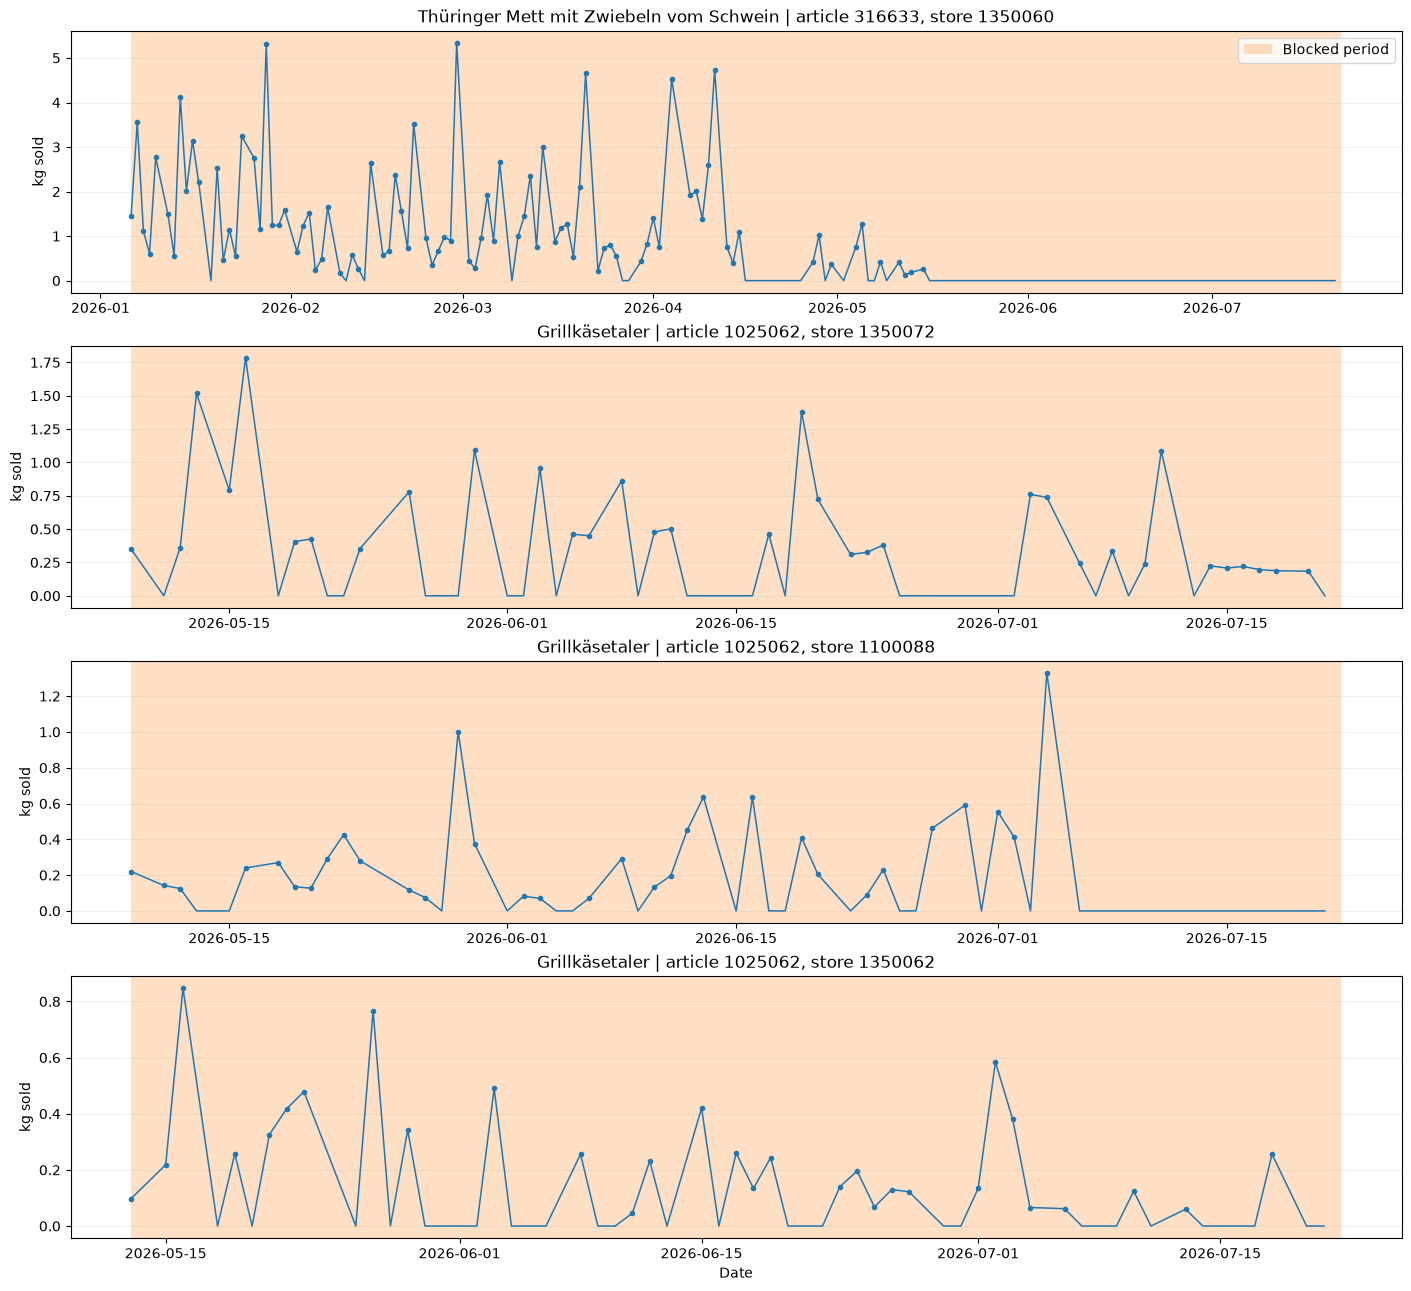

In [5]:
fig, axes = plt.subplots(len(examples), 1, figsize=(14, 3.2 * len(examples)), constrained_layout=True)
if len(examples) == 1:
    axes = [axes]

for ax, example in zip(axes, examples.itertuples(index=False)):
    start = pd.Timestamp(example.first_blocked) - pd.Timedelta(days=30)
    end = pd.Timestamp(example.last_blocked) + pd.Timedelta(days=30)
    series = con.execute(f'''
        SELECT CAST(DATE AS DATE) AS DATE, {DEMAND}, IS_BLOCKED
        FROM read_parquet(?)
        WHERE ARTIKEL_ID = ? AND MARKT_ID = ?
          AND CAST(DATE AS DATE) BETWEEN ? AND ?
        ORDER BY DATE
    ''', [DATA_GLOB, example.ARTIKEL_ID, example.MARKT_ID, start.date(), end.date()]).df()
    series['DATE'] = pd.to_datetime(series['DATE'])

    state_group = series['IS_BLOCKED'].ne(series['IS_BLOCKED'].shift()).cumsum()
    for _, run in series[series['IS_BLOCKED']].groupby(state_group):
        ax.axvspan(run['DATE'].min(), run['DATE'].max() + pd.Timedelta(days=1),
                   color='tab:orange', alpha=0.24, linewidth=0)
    ax.plot(series['DATE'], series[DEMAND], color='tab:blue', linewidth=1.1)
    ax.scatter(series.loc[series[DEMAND] > 0, 'DATE'],
               series.loc[series[DEMAND] > 0, DEMAND],
               color='tab:blue', s=9)
    ax.set_title(f"{example.ARTIKEL_BEZ} | article {example.ARTIKEL_ID}, store {example.MARKT_ID}")
    ax.set_ylabel('kg sold')
    ax.grid(axis='y', alpha=0.2)

axes[-1].set_xlabel('Date')
axes[0].legend(handles=[Patch(facecolor='tab:orange', alpha=0.24, label='Blocked period')],
               loc='upper right')
plt.show()

## Examples where blocks correspond entirely to zero demand

These examples show contiguous block episodes with zero `ABVERKAUFTE_MENGE_KG` on every blocked day. Each series must have a positive open-day sale in the preceding 30 days, and different articles are selected to keep the panels informative.

In [6]:
zero_examples = con.execute(f'''
    WITH source AS (
        SELECT *, CAST(DATE AS DATE) AS DATE_D
        FROM read_parquet(?)
    ),
    marked AS (
        SELECT *,
            CASE WHEN IS_BLOCKED != LAG(IS_BLOCKED) OVER (
                PARTITION BY ARTIKEL_ID, MARKT_ID ORDER BY DATE_D
            ) THEN 1 ELSE 0 END AS state_change
        FROM source
    ),
    grouped AS (
        SELECT *, SUM(state_change) OVER (
            PARTITION BY ARTIKEL_ID, MARKT_ID ORDER BY DATE_D
        ) AS block_group
        FROM marked
    ),
    zero_block_runs AS (
        SELECT ARTIKEL_ID, MARKT_ID, ANY_VALUE(ARTIKEL_BEZ) AS ARTIKEL_BEZ,
            COUNT(*) AS blocked_days, MIN(DATE_D) AS first_blocked,
            MAX(DATE_D) AS last_blocked
        FROM grouped
        WHERE IS_BLOCKED
        GROUP BY ARTIKEL_ID, MARKT_ID, block_group
        HAVING blocked_days >= 14
           AND COUNT_IF({DEMAND} > 0) = 0
    ),
    with_sale_context AS (
        SELECT b.*,
            COUNT_IF(NOT s.IS_BLOCKED AND s.{DEMAND} > 0) AS prior_30d_sales
        FROM zero_block_runs b
        JOIN source s ON s.ARTIKEL_ID = b.ARTIKEL_ID
          AND s.MARKT_ID = b.MARKT_ID
          AND s.DATE_D BETWEEN b.first_blocked - INTERVAL 30 DAY
                           AND b.first_blocked - INTERVAL 1 DAY
        GROUP BY ALL
        HAVING prior_30d_sales > 0
    ),
    ranked AS (
        SELECT *, ROW_NUMBER() OVER (
            PARTITION BY ARTIKEL_ID ORDER BY blocked_days, MARKT_ID
        ) AS article_choice
        FROM with_sale_context
    )
    SELECT ARTIKEL_ID, MARKT_ID, ARTIKEL_BEZ, blocked_days, prior_30d_sales,
           first_blocked, last_blocked
    FROM ranked
    WHERE article_choice = 1
    ORDER BY blocked_days, ARTIKEL_ID, MARKT_ID
    LIMIT 4
''', [DATA_GLOB]).df()
zero_examples

,ARTIKEL_ID,MARKT_ID,ARTIKEL_BEZ,blocked_days,prior_30d_sales,first_blocked,last_blocked
0,594727,1200006,Orig. italienischer Kochschinken mit grünem Sp...,410,3.0,2025-03-13,2026-07-21
1,910340,1300009,Frankreich Filetsteak vom Rind,602,1.0,2024-07-26,2026-07-21
2,911709,1100016,Frankreich Schmorbraten vom Rind,602,1.0,2024-07-26,2026-07-21
3,931261,1100039,"Roastbeef Non EU, geschlachtet in Brasilien",827,1.0,2023-10-27,2026-07-21


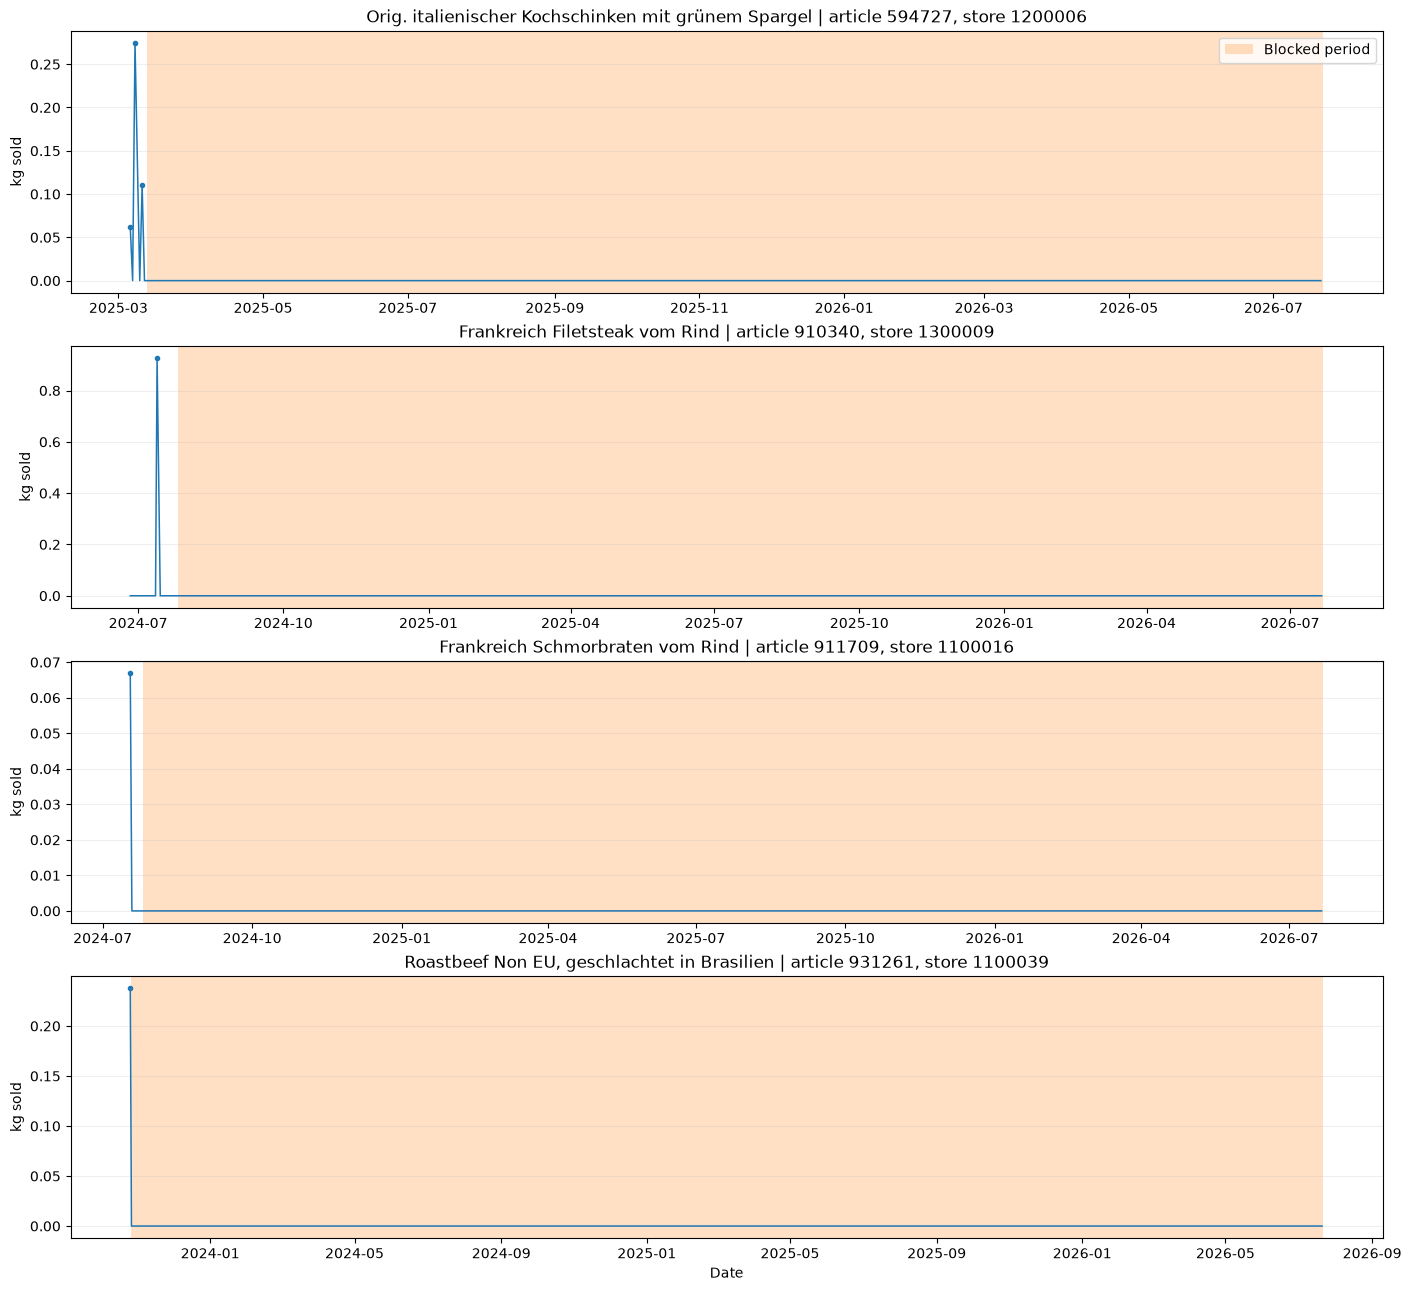

In [7]:
fig, axes = plt.subplots(len(zero_examples), 1, figsize=(14, 3.2 * len(zero_examples)), constrained_layout=True)
if len(zero_examples) == 1:
    axes = [axes]

for ax, example in zip(axes, zero_examples.itertuples(index=False)):
    start = pd.Timestamp(example.first_blocked) - pd.Timedelta(days=30)
    end = pd.Timestamp(example.last_blocked) + pd.Timedelta(days=30)
    series = con.execute(f'''
        SELECT CAST(DATE AS DATE) AS DATE, {DEMAND}, IS_BLOCKED
        FROM read_parquet(?)
        WHERE ARTIKEL_ID = ? AND MARKT_ID = ?
          AND CAST(DATE AS DATE) BETWEEN ? AND ?
        ORDER BY DATE
    ''', [DATA_GLOB, example.ARTIKEL_ID, example.MARKT_ID, start.date(), end.date()]).df()
    series['DATE'] = pd.to_datetime(series['DATE'])

    state_group = series['IS_BLOCKED'].ne(series['IS_BLOCKED'].shift()).cumsum()
    for _, run in series[series['IS_BLOCKED']].groupby(state_group):
        ax.axvspan(run['DATE'].min(), run['DATE'].max() + pd.Timedelta(days=1),
                   color='tab:orange', alpha=0.24, linewidth=0)
    ax.plot(series['DATE'], series[DEMAND], color='tab:blue', linewidth=1.1)
    ax.scatter(series.loc[series[DEMAND] > 0, 'DATE'],
               series.loc[series[DEMAND] > 0, DEMAND],
               color='tab:blue', s=9)
    ax.set_title(f"{example.ARTIKEL_BEZ} | article {example.ARTIKEL_ID}, store {example.MARKT_ID}")
    ax.set_ylabel('kg sold')
    ax.grid(axis='y', alpha=0.2)

axes[-1].set_xlabel('Date')
axes[0].legend(handles=[Patch(facecolor='tab:orange', alpha=0.24, label='Blocked period')],
               loc='upper right')
plt.show()

## Completed blocks followed by demand

These panels focus on the transition from blocked back to open. For each of the two articles with a completed block, one store with frequent and one with sparse post-block demand is shown. The window covers 90 days before and 120 days after the last blocked day.

In [8]:
completed_examples = con.execute(f'''
    WITH source AS (
        SELECT *, CAST(DATE AS DATE) AS DATE_D
        FROM read_parquet(?)
    ),
    marked AS (
        SELECT *, CASE WHEN IS_BLOCKED != LAG(IS_BLOCKED) OVER (
            PARTITION BY ARTIKEL_ID, MARKT_ID ORDER BY DATE_D
        ) THEN 1 ELSE 0 END AS state_change
        FROM source
    ),
    grouped AS (
        SELECT *, SUM(state_change) OVER (
            PARTITION BY ARTIKEL_ID, MARKT_ID ORDER BY DATE_D
        ) AS state_group
        FROM marked
    ),
    block_runs AS (
        SELECT ARTIKEL_ID, MARKT_ID, ANY_VALUE(ARTIKEL_BEZ) AS ARTIKEL_BEZ,
            MIN(DATE_D) AS block_start, MAX(DATE_D) AS block_end,
            COUNT(*) AS blocked_days,
            COUNT_IF({DEMAND} > 0) AS positive_blocked_days
        FROM grouped
        WHERE IS_BLOCKED
        GROUP BY ARTIKEL_ID, MARKT_ID, state_group
    ),
    completed AS (
        SELECT b.*,
            COUNT_IF(s.DATE_D > b.block_end AND s.{DEMAND} > 0) AS positive_days_after
        FROM block_runs b
        JOIN source s USING (ARTIKEL_ID, MARKT_ID)
        GROUP BY ALL
        HAVING b.block_end < MAX(s.DATE_D) AND positive_days_after > 0
    ),
    ranked AS (
        SELECT *,
            ROW_NUMBER() OVER (PARTITION BY ARTIKEL_ID ORDER BY positive_days_after DESC) AS frequent_rank,
            ROW_NUMBER() OVER (PARTITION BY ARTIKEL_ID ORDER BY positive_days_after, MARKT_ID) AS sparse_rank
        FROM completed
    )
    SELECT ARTIKEL_ID, MARKT_ID, ARTIKEL_BEZ, block_start, block_end,
           blocked_days, positive_blocked_days, positive_days_after,
           CASE WHEN frequent_rank = 1 THEN 'frequent after' ELSE 'sparse after' END AS example_type
    FROM ranked
    WHERE frequent_rank = 1 OR sparse_rank = 1
    ORDER BY ARTIKEL_ID, example_type
''', [DATA_GLOB]).df()
completed_examples

,ARTIKEL_ID,MARKT_ID,ARTIKEL_BEZ,block_start,block_end,blocked_days,positive_blocked_days,positive_days_after,example_type
0,316633,1300024,Thüringer Mett mit Zwiebeln vom Schwein,2023-07-22,2024-04-20,228,228.0,681.0,frequent after
1,316633,1300021,Thüringer Mett mit Zwiebeln vom Schwein,2023-09-12,2024-04-20,184,4.0,1.0,sparse after
2,388785,1300024,Argentinien Rinderroastbeef,2023-10-24,2024-12-18,351,8.0,27.0,frequent after
3,388785,1300019,Argentinien Rinderroastbeef,2023-12-28,2024-12-18,298,6.0,1.0,sparse after


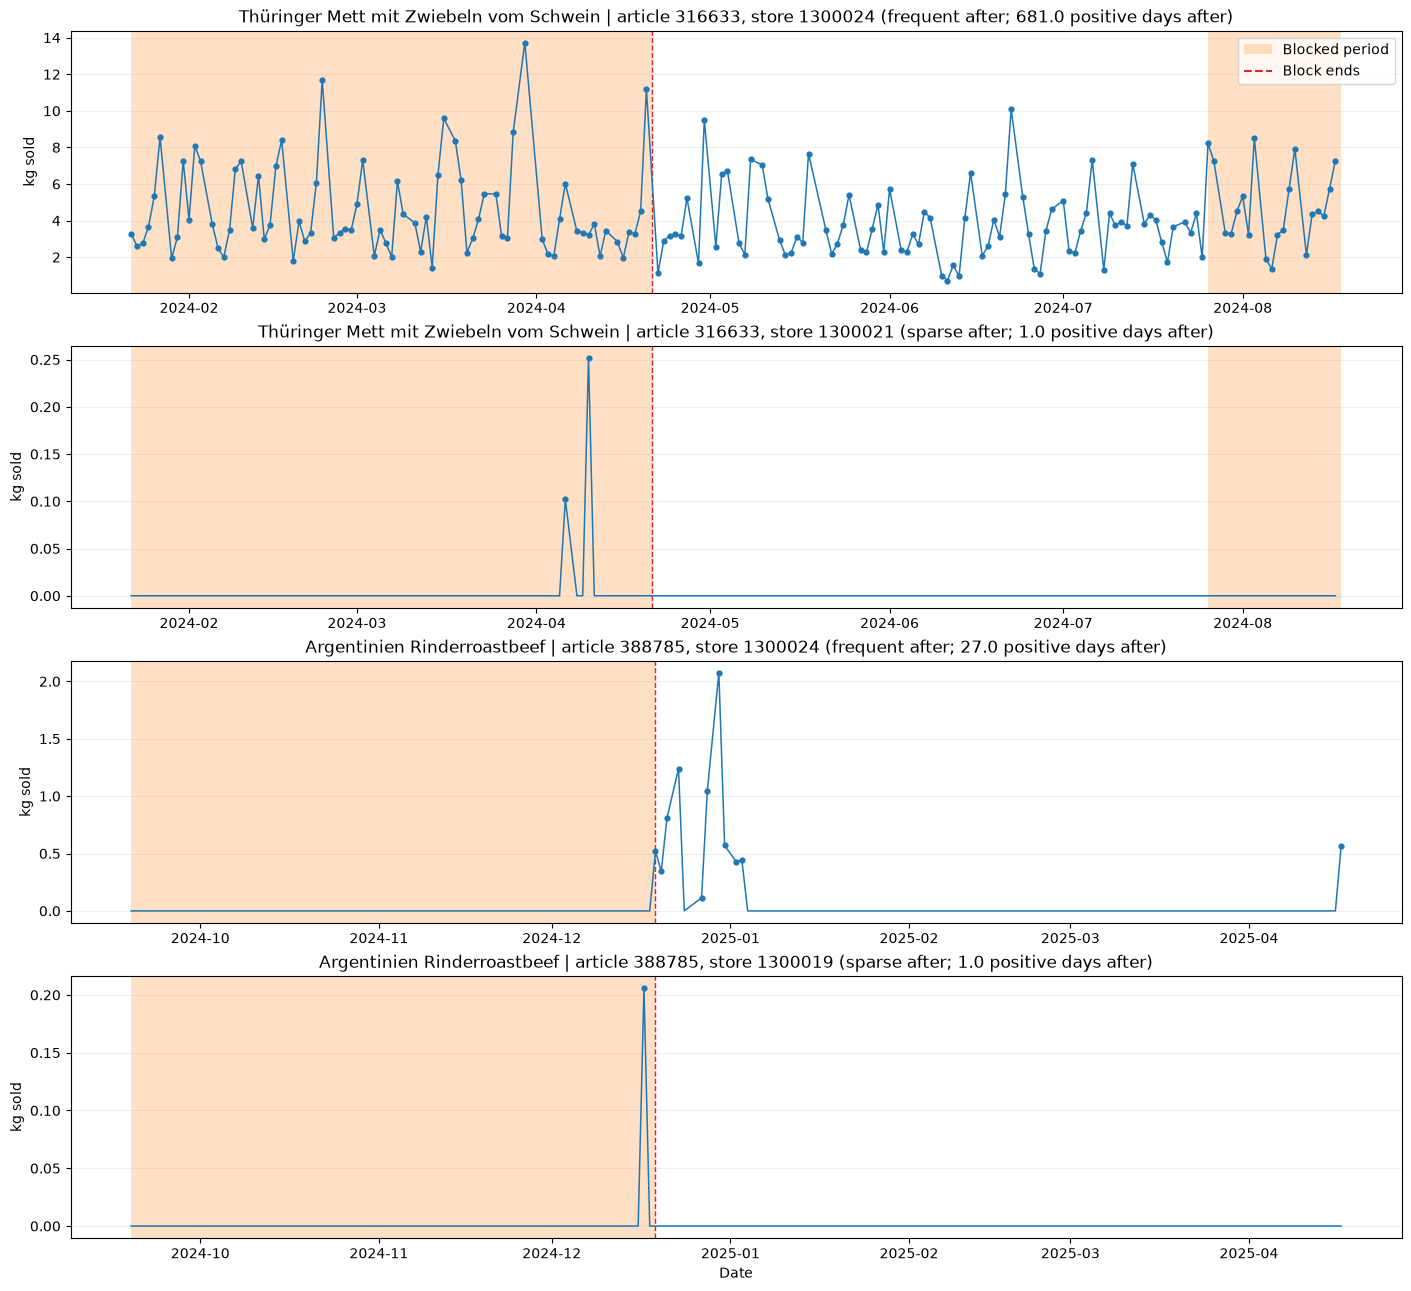

In [9]:
fig, axes = plt.subplots(len(completed_examples), 1, figsize=(14, 3.2 * len(completed_examples)), constrained_layout=True)
if len(completed_examples) == 1:
    axes = [axes]

for ax, example in zip(axes, completed_examples.itertuples(index=False)):
    start = pd.Timestamp(example.block_end) - pd.Timedelta(days=90)
    end = pd.Timestamp(example.block_end) + pd.Timedelta(days=120)
    series = con.execute(f'''
        SELECT CAST(DATE AS DATE) AS DATE, {DEMAND}, IS_BLOCKED
        FROM read_parquet(?)
        WHERE ARTIKEL_ID = ? AND MARKT_ID = ?
          AND CAST(DATE AS DATE) BETWEEN ? AND ?
        ORDER BY DATE
    ''', [DATA_GLOB, example.ARTIKEL_ID, example.MARKT_ID, start.date(), end.date()]).df()
    series['DATE'] = pd.to_datetime(series['DATE'])

    state_group = series['IS_BLOCKED'].ne(series['IS_BLOCKED'].shift()).cumsum()
    for _, run in series[series['IS_BLOCKED']].groupby(state_group):
        ax.axvspan(run['DATE'].min(), run['DATE'].max() + pd.Timedelta(days=1),
                   color='tab:orange', alpha=0.24, linewidth=0)
    ax.axvline(pd.Timestamp(example.block_end) + pd.Timedelta(days=1),
               color='tab:red', linestyle='--', linewidth=1, label='Block ends')
    ax.plot(series['DATE'], series[DEMAND], color='tab:blue', linewidth=1.1)
    ax.scatter(series.loc[series[DEMAND] > 0, 'DATE'],
               series.loc[series[DEMAND] > 0, DEMAND], color='tab:blue', s=12)
    ax.set_title(
        f"{example.ARTIKEL_BEZ} | article {example.ARTIKEL_ID}, store {example.MARKT_ID} "
        f"({example.example_type}; {example.positive_days_after} positive days after)"
    )
    ax.set_ylabel('kg sold')
    ax.grid(axis='y', alpha=0.2)

axes[-1].set_xlabel('Date')
axes[0].legend(handles=[
    Patch(facecolor='tab:orange', alpha=0.24, label='Blocked period'),
    plt.Line2D([], [], color='tab:red', linestyle='--', label='Block ends'),
], loc='upper right')
plt.show()

## How many block periods are there?

Repeated status snapshots are collapsed into logical continuous block periods. Counts are shown both for the raw article–mandant history and for episodes overlapping prepared article–store series. A block with no later `FREE` status is treated as continuing through today.

In [10]:
BLOCK_FILE = str(ROOT / 'data/raw/artikel_markt_sperre/artikel_markt_sperre.csv')
TODAY = pd.Timestamp.today().normalize().date()

raw_counts = con.execute('''
    WITH raw_history AS (
        SELECT row_number() OVER () AS source_row, ARTIKEL_ID, APMAND,
               CAST(AENDERUNGSDATUM AS DATE) AS event_date,
               upper(trim(AVAILABILITY_STATUS)) AS status
        FROM read_csv_auto(?, header=true, sample_size=-1, dateformat='%d.%m.%Y')
        WHERE upper(trim(AVAILABILITY_STATUS)) IN ('BLOCKED', 'FREE')
    ),
    daily_states AS (
        SELECT ARTIKEL_ID, APMAND, event_date, arg_max(status, source_row) AS status
        FROM raw_history GROUP BY ARTIKEL_ID, APMAND, event_date
    ),
    marked AS (
        SELECT *, lag(status) OVER (
            PARTITION BY ARTIKEL_ID, APMAND ORDER BY event_date
        ) AS previous_status
        FROM daily_states
    ),
    status_events AS (
        SELECT * FROM marked
        WHERE previous_status IS NULL OR status != previous_status
    ),
    periods AS (
        SELECT *, lead(event_date) OVER (
            PARTITION BY ARTIKEL_ID, APMAND ORDER BY event_date
        ) AS block_end
        FROM status_events
    )
    SELECT COUNT(*) AS overall_blocks,
           COUNT_IF(block_end IS NULL) AS ongoing_through_today,
           MAX(event_date) AS latest_status_date
    FROM periods WHERE status = 'BLOCKED'
''', [BLOCK_FILE]).df()

series_counts = con.execute('''
    WITH source AS (
        SELECT ARTIKEL_ID, MARKT_ID, CAST(DATE AS DATE) AS date_d, IS_BLOCKED
        FROM read_parquet(?)
    ),
    marked AS (
        SELECT *, CASE WHEN IS_BLOCKED != lag(IS_BLOCKED) OVER (
            PARTITION BY ARTIKEL_ID, MARKT_ID ORDER BY date_d
        ) THEN 1 ELSE 0 END AS state_change
        FROM source
    ),
    grouped AS (
        SELECT *, SUM(state_change) OVER (
            PARTITION BY ARTIKEL_ID, MARKT_ID ORDER BY date_d
        ) AS state_group
        FROM marked
    ),
    block_runs AS (
        SELECT ARTIKEL_ID, MARKT_ID, state_group, MAX(date_d) AS block_end
        FROM grouped WHERE IS_BLOCKED GROUP BY ALL
    ),
    series_end AS (SELECT MAX(date_d) AS latest_data_date FROM source)
    SELECT COUNT(*) AS observed_series_blocks,
           COUNT_IF(block_end = latest_data_date) AS ongoing_at_latest_data_date,
           latest_data_date
    FROM block_runs CROSS JOIN series_end GROUP BY latest_data_date
''', [DATA_GLOB]).df()

display(raw_counts.assign(today=TODAY))
display(series_counts.assign(today=TODAY))

,overall_blocks,ongoing_through_today,latest_status_date,today
0,2800,2316.0,2026-07-08,2026-07-21


,observed_series_blocks,ongoing_at_latest_data_date,latest_data_date,today
0,2091,2061.0,2026-07-21,2026-07-21


In [11]:
r = raw_counts.iloc[0]
s = series_counts.iloc[0]
print(
    f"Raw history: {int(r.overall_blocks):,} logical blocks overall; "
    f"{int(r.ongoing_through_today):,} remain blocked through {TODAY}.\n"
    f"Prepared series: {int(s.observed_series_blocks):,} observed block episodes overall; "
    f"{int(s.ongoing_at_latest_data_date):,} reach the latest data date "
    f"({s.latest_data_date})."
)

Raw history: 2,800 logical blocks overall; 2,316 remain blocked through 2026-07-21.
Prepared series: 2,091 observed block episodes overall; 2,061 reach the latest data date (2026-07-21 00:00:00).
